# 03 - Likelihood and frequentist inference

**Goal.** Meet the likelihood function, the one ingredient that Bayesian and
classical statistics share. We derive maximum likelihood estimates for three standard
models, build the usual confidence interval from the curvature of the log-likelihood,
and then look hard at what a confidence interval does and does not promise. That
last point is the motivation for the posterior in chapter 04.

## 1. The likelihood function

A statistical model gives the probability (or density) of the data for each value of
the parameter, $f(y\mid\theta)$. Once the data $y$ are observed and fixed, the same
formula read as a function of $\theta$ is the **likelihood**
$$ L(\theta) = f(y\mid\theta). $$
For independent observations it is a product, and its logarithm is a sum:
$$ L(\theta) = \prod_{i=1}^n f(y_i\mid\theta), \qquad \ell(\theta) = \log L(\theta) = \sum_{i=1}^n \log f(y_i\mid\theta). $$
Two warnings. The likelihood is **not** a probability distribution for $\theta$: it
need not integrate to one over $\theta$, and constants that do not involve $\theta$
can be dropped without changing anything. And in code, always work with $\ell$
rather than $L$: a product of hundreds of small numbers underflows to zero.

**Example.** A basketball player takes 20 free throws and makes 13. If throws are
independent with success probability $\theta$, then
$L(\theta) = \binom{20}{13}\theta^{13}(1-\theta)^{7} \propto \theta^{13}(1-\theta)^7$.

## 2. Maximum likelihood

The **maximum likelihood estimate** (MLE) is the parameter value that makes the
observed data most probable, $\hat\theta = \arg\max_\theta \ell(\theta)$. Because the
logarithm is increasing, maximising $\ell$ and $L$ give the same answer, and $\ell$
is easier to differentiate.

**Bernoulli / binomial.** With $y$ successes in $n$ trials,
$\ell(\theta) = y\log\theta + (n-y)\log(1-\theta)$ + const. Setting the derivative to zero,
$$ \frac{y}{\theta} - \frac{n-y}{1-\theta} = 0 \quad\Longrightarrow\quad \hat\theta = \frac{y}{n}. $$

**Exponential.** For waiting times $y_i\sim$ Exponential$(\lambda)$,
$\ell(\lambda) = n\log\lambda - \lambda\sum_i y_i$, so $n/\lambda - \sum_i y_i = 0$ and
$\hat\lambda = 1/\bar y$.

**Normal mean.** For $y_i\sim$ Normal$(\mu,\sigma^2)$ with $\sigma$ known,
$\ell(\mu) = -\frac{1}{2\sigma^2}\sum_i (y_i-\mu)^2$ + const. Then
$\ell'(\mu) = \frac{1}{\sigma^2}\sum_i(y_i-\mu) = 0$ gives $\hat\mu = \bar y$. If $\sigma^2$
is also unknown, the same approach gives $\hat\sigma^2 = \frac1n\sum_i(y_i-\bar y)^2$,
which is slightly biased low (the unbiased version divides by $n-1$).

Each of these is the answer intuition suggests. The machinery earns its keep on
harder models, where no intuition is available but the recipe is unchanged. The code
plots the free-throw likelihood and log-likelihood and confirms the maximum
numerically.

numerical MLE = 0.6500,   y/n = 0.6500


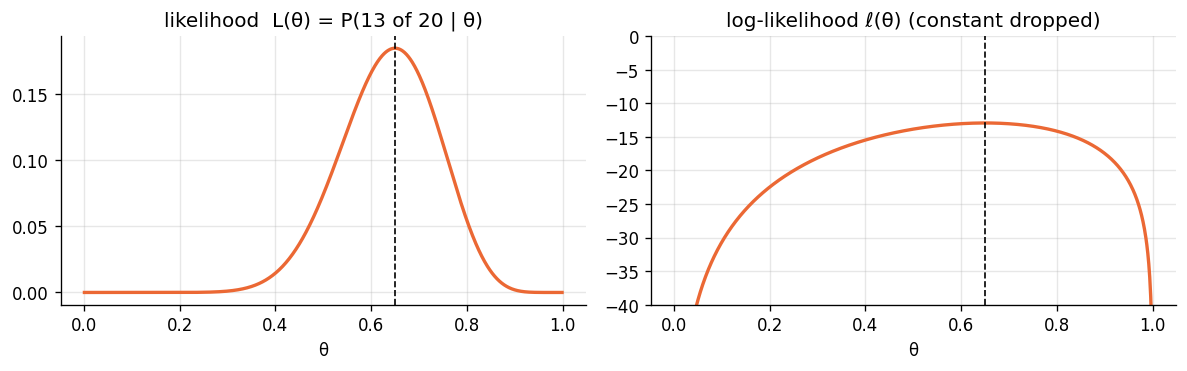

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(3)

n, y = 20, 13
loglik = lambda t: y * np.log(t) + (n - y) * np.log(1 - t)
res = optimize.minimize_scalar(lambda t: -loglik(t), bounds=(1e-9, 1 - 1e-9), method="bounded")
print(f"numerical MLE = {res.x:.4f},   y/n = {y / n:.4f}")

theta = np.linspace(0.001, 0.999, 999)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(theta, stats.binom.pmf(y, n, theta), color=LIK, lw=2)
ax[0].set_title("likelihood  L(θ) = P(13 of 20 | θ)"); ax[0].set_xlabel("θ")
ax[1].plot(theta, loglik(theta), color=LIK, lw=2); ax[1].set_ylim(-40, 0)
ax[1].set_title("log-likelihood ℓ(θ) (constant dropped)"); ax[1].set_xlabel("θ")
for a in ax:
    a.axvline(y / n, color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

## 3. Curvature, Fisher information and standard errors

How sure should we be of $\hat\theta$? A sharply peaked log-likelihood means the data
rule out values away from the peak; a flat one means they do not. Curvature is
measured by the second derivative. The **observed information** is
$J(\hat\theta) = -\ell''(\hat\theta)$, and for large $n$ the MLE is approximately
normal [1, 3]:
$$ \hat\theta \;\dot\sim\; \text{Normal}\!\left(\theta,\ \frac{1}{J(\hat\theta)}\right), \qquad
   \text{SE}(\hat\theta) = \frac{1}{\sqrt{J(\hat\theta)}}. $$
For the binomial, $\ell''(\theta) = -\frac{y}{\theta^2} - \frac{n-y}{(1-\theta)^2}$. At
$\hat\theta = y/n$ this simplifies to $-\frac{n}{\hat\theta(1-\hat\theta)}$, so
$$ \text{SE}(\hat\theta) = \sqrt{\frac{\hat\theta(1-\hat\theta)}{n}}. $$
More data means more curvature: the standard error shrinks like $1/\sqrt n$.

## 4. Confidence intervals

The approximate normality gives the familiar **95% confidence interval**
(the Wald interval)
$$ \hat\theta \pm 1.96\,\text{SE}(\hat\theta). $$
For the free throws, $\hat\theta = 0.65$ and the SE is $\sqrt{0.65\cdot0.35/20}\approx 0.107$,
so the interval is roughly $(0.44, 0.86)$.

What does "95%" mean here? In frequentist statistics $\theta$ is a fixed constant,
not a random variable, so it is not in any interval "with probability 0.95". The
randomness is in the **data**, and therefore in the interval. The guarantee is about
the procedure [4]:

> If you repeated the experiment many times and computed an interval each time, about
> 95% of those intervals would contain the true $\theta$.

Any one computed interval, such as $(0.44, 0.86)$, either contains $\theta$ or does
not. The simulation draws 60 repeated experiments with a true $\theta = 0.65$ and
shows which intervals miss.

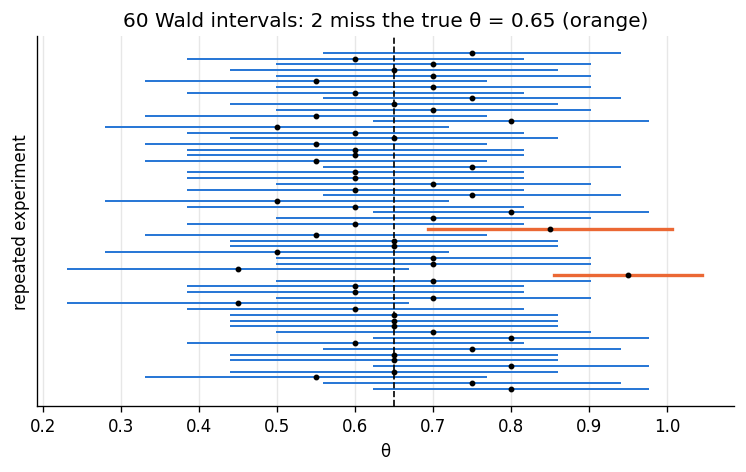

In [2]:
def wald(y, n, z=1.96):
    t = y / n
    se = np.sqrt(t * (1 - t) / n)
    return t - z * se, t + z * se

true_theta, n = 0.65, 20
ys = rng.binomial(n, true_theta, size=60)
lo, hi = wald(ys, n)
miss = (lo > true_theta) | (hi < true_theta)
plt.figure(figsize=(7.5, 4))
for i in range(len(ys)):
    plt.plot([lo[i], hi[i]], [i, i], color=LIK if miss[i] else POST, lw=2 if miss[i] else 1.2)
    plt.plot(ys[i] / n, i, "o", color="k", ms=2.5)
plt.axvline(true_theta, color="k", ls="--", lw=1)
plt.xlabel("θ"); plt.ylabel("repeated experiment"); plt.yticks([])
plt.title(f"60 Wald intervals: {miss.sum()} miss the true θ = 0.65 (orange)")
plt.show()

## 5. When the guarantee fails

The 95% promise rests on a large-sample normal approximation. For a binomial with a
small $n$ or $\theta$ near 0 or 1, it can be badly wrong [5]. Because $y$ takes only
$n+1$ values, we can compute the true coverage **exactly**: for each possible $y$,
check whether its interval contains $\theta$, and add up the probabilities of the $y$
values for which it does:
$$ \text{coverage}(\theta) = \sum_{y=0}^{n} \binom ny\theta^y(1-\theta)^{n-y}\; I_{\{\theta\in \text{CI}(y)\}}. $$

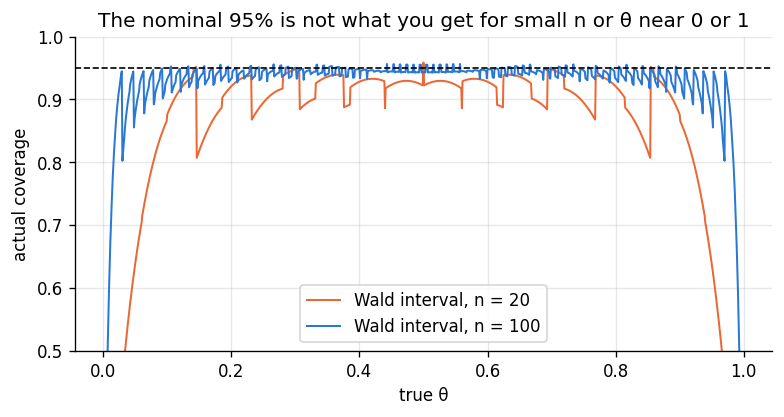

coverage at θ = 0.05, n = 20: 0.639


In [3]:
def coverage(theta, n, interval):
    ys = np.arange(n + 1)
    lo, hi = interval(ys, n)
    inside = (lo <= theta) & (theta <= hi)
    return stats.binom.pmf(ys, n, theta)[inside].sum()

grid = np.linspace(0.005, 0.995, 991)
for n_, color in [(20, LIK), (100, POST)]:
    cov = [coverage(t, n_, wald) for t in grid]
    plt.plot(grid, cov, color=color, lw=1.2, label=f"Wald interval, n = {n_}")
plt.axhline(0.95, color="k", ls="--", lw=1)
plt.ylim(0.5, 1.0); plt.xlabel("true θ"); plt.ylabel("actual coverage")
plt.title("The nominal 95% is not what you get for small n or θ near 0 or 1")
plt.legend(); plt.show()
print(f"coverage at θ = 0.05, n = 20: {coverage(0.05, 20, wald):.3f}")

At $\theta = 0.05$ with $n=20$ the "95%" interval covers the truth only about two
times in three (the code prints the exact figure), and closer to the edges it is
worse still. The main culprit is that when $y = 0$ the
estimated SE is zero and the interval collapses to the single point $\{0\}$. Better
frequentist intervals exist [5], and chapter 05 shows that a simple Bayesian interval
behaves well here too.

## 6. What the likelihood alone cannot answer

Frequentist inference answers questions about the **procedure**: how often would
this method be right over repeated data? It deliberately does not assign
probabilities to $\theta$. So these natural questions have no direct frequentist
answer:

- Given these 20 throws, what is the probability that $\theta > 0.5$?
- What range of $\theta$ values is 95% probable, given what we saw?
- If there is a strong reason (years of data on similar players) to expect $\theta$
  near 0.75, how should that change the conclusion from only 20 throws?

All three are questions about $\theta$ **given the data**, and answering them needs
a distribution for $\theta$. Combine the likelihood with a prior and you get exactly
that: the posterior. That is chapter 04.

### Exercises

1. For $y_i\sim$ Poisson$(\lambda)$, derive the MLE $\hat\lambda$ and its standard
   error from the observed information.
2. Derive the MLE of $\sigma^2$ for normal data with known mean $\mu$.
3. For the exponential model, show that $J(\hat\lambda) = n/\hat\lambda^2$ and write
   the Wald interval for $\lambda$. Is the interval symmetric? Is that sensible for a
   positive parameter?
4. Implement the Wilson interval (see [5]) and add its coverage curve to the plot.
   How does it compare with the Wald interval for $n = 20$?
5. A colleague says "the 95% confidence interval is (0.44, 0.86), so there is a 95%
   chance that θ is between 0.44 and 0.86." Explain precisely what is wrong, then
   explain what additional ingredient would make a statement of that form valid.

## References

1. R. A. Fisher. *On the mathematical foundations of theoretical statistics.* Philosophical Transactions of the Royal Society A, 222:309-368, 1922. doi:10.1098/rsta.1922.0009
2. J. Neyman. *Outline of a theory of statistical estimation based on the classical theory of probability.* Philosophical Transactions of the Royal Society A, 236:333-380, 1937. doi:10.1098/rsta.1937.0005
3. G. Casella, R. L. Berger. *Statistical Inference*, 2nd ed. Duxbury, 2002. (Chapters 7 and 10.)
4. L. Wasserman. *All of Statistics.* Springer, 2004. (Chapters 6 and 9.)
5. L. D. Brown, T. T. Cai, A. DasGupta. *Interval Estimation for a Binomial Proportion.* Statistical Science, 16(2):101-133, 2001. doi:10.1214/ss/1009213286
6. A. Agresti, B. A. Coull. *Approximate is better than "exact" for interval estimation of binomial proportions.* The American Statistician, 52(2):119-126, 1998. doi:10.1080/00031305.1998.10480550